In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn import Linear, Parameter
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
#from math_utils import acos, arcosh
#from product_distance_v2 import ProductDistance, acosh
import networkx as nx 
import math
import numpy as np
import matplotlib.pyplot as plt

from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.FormanRicci import FormanRicci
    
import community.community_louvain as community_louvain

from sklearn import preprocessing, metrics

from torch_geometric.datasets import WebKB
from torch_geometric.utils import to_networkx, k_hop_subgraph
from torch_geometric.nn import GCNConv
import random

In [2]:
def dot(x,y): return torch.sum(x * y, -1)
def acosh(x):
    return torch.log(x + torch.sqrt(x**2-1))

In [3]:
class RParameter(nn.Parameter):
    def __new__(cls, data=None, requires_grad=True, sizes=None, exp=False):
        if data is None:
            assert sizes is not None
            data = (1e-3 * torch.randn(sizes, dtype=torch.double)).clamp_(min=-3e-3,max=3e-3)
        #TODO get partial data if too big i.e. data[0:n,0:d]
        ret =  super().__new__(cls, data, requires_grad=requires_grad)
        # ret.data    = data
        ret.initial_proj()
        ret.use_exp = exp
        return ret

    @staticmethod
    def _proj(x):
        raise NotImplemented

    def proj(self):
        self.data = self.__class__._proj(self.data.detach())
        # print(torch.norm(self.data, dim=-1))

    def initial_proj(self):
        """ Project the initialization of the embedding onto the manifold """
        self.proj()

    def modify_grad_inplace(self):
        pass

    @staticmethod
    def correct_metric(ps):
        for p in ps:
            if isinstance(p,RParameter):
                p.modify_grad_inplace()


In [4]:
class PoincareParameter(RParameter):
    def __new__(cls, data=None, requires_grad=True, sizes=None, check_graph=False):
        ret =  super().__new__(cls, data, requires_grad, sizes)
        ret.check_graph = check_graph
        return ret

    def modify_grad_inplace(self):
        # d        = self.data.dim()
        w_norm   = torch.norm(self.data,2,-1, True)
        # This is the inverse of the remanian metric, which we need to correct for.
        hyper_b  = (1 - w_norm**2)**2/4
        # new_size = tuple([1] * (d - 1) + [self.data.size(d-1)])
        # self.grad   *= hyper_b.repeat(*new_size) # multiply pointwise
        self.grad   *= hyper_b # multiply pointwise
        self.grad.clamp_(min=-10000.0, max=10000.0)

        # We could do the projection here?
        # NB: THIS IS DEATHLY SLOW. FIX IT
        if self.check_graph and np.any(np.isnan(self.grad.data.cpu().numpy())):
             print(np.any(np.isnan(self.data.cpu().numpy())))
             print(np.any(np.isnan(self.grad.data.cpu().numpy())))
             print(np.any(np.isnan(w_norm.cpu().numpy())))
             raise ValueError("NaN During Hyperbolic")

    @staticmethod
    def _correct(x, eps=1e-10):
        current_norms = torch.norm(x,2,x.dim() - 1)
        mask_idx      = current_norms < 1./(1+eps)
        modified      = 1./((1+eps)*current_norms)
        modified[mask_idx] = 1.0
        #new_size      = [1]*current_norms.dim() + [x.size(x.dim()-1)]
        #return modified.unsqueeze(modified.dim()).repeat(*new_size)
        # return modified.unsqueeze(modified.dim()).expand(x.size())
        return modified.unsqueeze(-1)

    @staticmethod
    def _proj(x, eps=1e-10):
        return x * PoincareParameter._correct(x, eps=eps)

    # def proj(self, eps=1e-10):
    #     self.data = self.__class__._proj(self.data.detach())#PoincareParameter._correct(self.data, eps=eps)

    def __repr__(self):
        return 'Hyperbolic parameter containing:' + self.data.__repr__()


In [5]:
class SphericalParameter(RParameter):
    def __new__(cls, data=None, requires_grad=True, sizes=None, exp=True):
        if sizes is not None:
            sizes = list(sizes)
            sizes[-1] += 1
        return super().__new__(cls, data, requires_grad, sizes, exp)


    def modify_grad_inplace(self):
        """ Convert Euclidean gradient into Riemannian by projecting onto tangent space """
        # pass
        self.grad -= dot(self.data, self.grad).unsqueeze(-1) * self.data

    def exp(self, lr):
        x = self.data.detach()
        v = -lr*self.grad

        retract = False
        if retract:
        # retraction
            self.data = x + v

        else:
            n = torch.norm(v, 2, -1, keepdim=True)
            mask = torch.abs(n)<1e-7
            cos = torch.cos(n)
            cos[mask] = 1.0
            sin = torch.sin(n)
            sin[mask] = 0.0
            n[torch.abs(n)<1e-7] = 1.0
            e = cos*x + sin*v/n
            self.data = e
        self.proj()

    @staticmethod
    def _proj(x):
        # return x / torch.norm(x, 2, -1).unsqueeze(-1)
        return x / torch.norm(x, 2, -1, True)

    # def proj(self):
    #     x = self.data.detach()
    #     self.data = SphericalParameter._proj(x)
    def initial_proj(self):
        # pass
        self.data[...,0] = torch.sqrt(1 - torch.norm(self.data[...,1:],2,-1)**2)


In [6]:
class EuclideanParameter(RParameter):
    def proj(x):
        pass

In [7]:
def dist_p(u,v):
    z  = 2*torch.norm(u-v,2,-1)**2
    uu = 1. + torch.div(z,((1-torch.norm(u,2,-1)**2)*(1-torch.norm(v,2,-1)**2)))
    # machine_eps = np.finfo(uu.data.numpy().dtype).eps  # problem with cuda tensor
    # return acosh(torch.clamp(uu, min=1+machine_eps))
    return acosh(uu)

In [8]:
def dot(x,y): return torch.sum(x * y, -1)


In [9]:
def dist_e(u, v):
    """ Input shape (n, d) """
    return torch.norm(u-v, 2, dim=-1)

In [10]:
def dist_s(u, v, eps=1e-9):
    uu = SphericalParameter._proj(u)
    vv = SphericalParameter._proj(v)
    return torch.acos(torch.clamp(dot(uu, vv), -1+eps, 1-eps))

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = WebKB(root="/home/siddy/META/data", name='cornell')
data = dataset[0]

In [12]:
feat = data.x
print(feat.shape)

torch.Size([183, 1703])


In [13]:
G = to_networkx(data, to_undirected=True)

In [14]:
def init_ball(radius: int, graph):
    edge_dict = {}
    for index, node in enumerate(graph.nodes()):
        paths = nx.single_source_shortest_path(graph, node, radius)
        if index not in edge_dict:
            edge_dict[index] = []
        for key, value in paths.items():
            if len(value) == 2:
                edge_dict[index].append(value)
            elif len(value)==3:
                edge_dict[index].append(value[1:])
    return edge_dict

In [15]:
edge_dict= init_ball(radius=2, graph=G)

In [16]:
edge_dict

{0: [[0, 101], [0, 122], [101, 8], [101, 20], [101, 109]],
 1: [[1, 27], [27, 74], [27, 97]],
 2: [[2, 75], [2, 130], [75, 25], [75, 66]],
 3: [],
 4: [],
 5: [],
 6: [[6, 109],
  [6, 149],
  [109, 8],
  [109, 20],
  [109, 57],
  [109, 101],
  [109, 122],
  [149, 165]],
 7: [],
 8: [[8, 28],
  [8, 101],
  [8, 109],
  [8, 122],
  [8, 158],
  [28, 21],
  [28, 24],
  [28, 47],
  [28, 84],
  [101, 0],
  [101, 20],
  [109, 6],
  [109, 57],
  [158, 31],
  [158, 65],
  [158, 147]],
 9: [[9, 148], [148, 57], [148, 67]],
 10: [[10, 142], [10, 154], [10, 166], [154, 57]],
 11: [],
 12: [],
 13: [[13, 150], [150, 66], [150, 89], [150, 110], [150, 146]],
 14: [],
 15: [],
 16: [],
 17: [],
 18: [[18, 96], [96, 57], [96, 70], [96, 121], [96, 173]],
 19: [[19, 103], [103, 57], [103, 83]],
 20: [[20, 47],
  [20, 101],
  [20, 109],
  [20, 158],
  [47, 24],
  [47, 28],
  [101, 0],
  [101, 8],
  [101, 122],
  [109, 6],
  [109, 57],
  [158, 31],
  [158, 65],
  [158, 147]],
 21: [[21, 28],
  [21, 41],
  [

In [17]:
class Edge_atten(nn.Module):
    def __init__(self, in_channels, out_channels, num_heads=1, concat_heads=True, alpha=0.2):
        super().__init__()
        self.num_heads=num_heads
        self.concat_heads = concat_heads
        if self.concat_heads:
            assert out_channels % num_heads==0, "number of output channels must be multiple of count of heads"
            out_channels = out_channels // num_heads

        self.linear = nn.Linear(in_channels, out_channels*num_heads)
        self.a = nn.Parameter(torch.Tensor(num_heads, 2*out_channels))
        self.leakyrelu = nn.LeakyReLU(alpha)

        #xavier uniform initialization
        nn.init.xavier_uniform_(self.linear.weight.data, gain=1.414)
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
    
    def forward(self, node_feats, edge_index):
        node_feats = torch.unsqueeze(node_feats, dim=0)
        batch_size, num_nodes = node_feats.size(0), node_feats.size(1)
        node_feats = self.linear(node_feats)
        node_feats = node_feats.view(batch_size, num_nodes, self.num_heads, -1)
        node_feats_flat = node_feats.view(batch_size*num_nodes, self.num_heads, -1)
        edge_indices_row = edge_index[0]
        edge_indices_col = edge_index[1]
        a_input = torch.cat([
            torch.index_select(input=node_feats_flat, index=edge_indices_row, dim=0),
            torch.index_select(input=node_feats_flat, index=edge_indices_col, dim=0)
        ], dim=-1)
        attn_logits = torch.einsum('bhc, hc->bh', a_input, self.a)
        attn_logits = self.leakyrelu(attn_logits)
        attn_probs = F.softmax(attn_logits, dim=-2)
        return attn_probs

In [18]:
edge_list = torch.permute(torch.tensor(edge_dict[0], dtype=torch.long), (1,0))
print(edge_list)

tensor([[  0,   0, 101, 101, 101],
        [101, 122,   8,  20, 109]])


In [19]:
edge_list_nx = list(tuple(i) for x,i in enumerate(edge_list.t().numpy()))
print(edge_list_nx)

[(0, 101), (0, 122), (101, 8), (101, 20), (101, 109)]


In [19]:
g_ball = nx.Graph()
g_ball.add_edges_from(edge_list_nx)

In [20]:
orc = OllivierRicci(g_ball, alpha=0.5, verbose="TRACE")

In [21]:
orc.compute_ricci_curvature()
G_orc = orc.G.copy()

In [22]:
ricci_curvtures = nx.get_edge_attributes(G_orc, "ricciCurvature")

In [23]:
ricci_curvtures

{(0, 101): -0.25,
 (0, 122): 0.5,
 (101, 8): 0.25,
 (101, 20): 0.25,
 (101, 109): 0.25}

Ball graph of center node 0
Ricci curvature of edge (0,101) is -0.250000
Ricci curvature of edge (0,122) is 0.500000
Ricci curvature of edge (101,8) is 0.250000
Ricci curvature of edge (101,20) is 0.250000
Ricci curvature of edge (101,109) is 0.250000


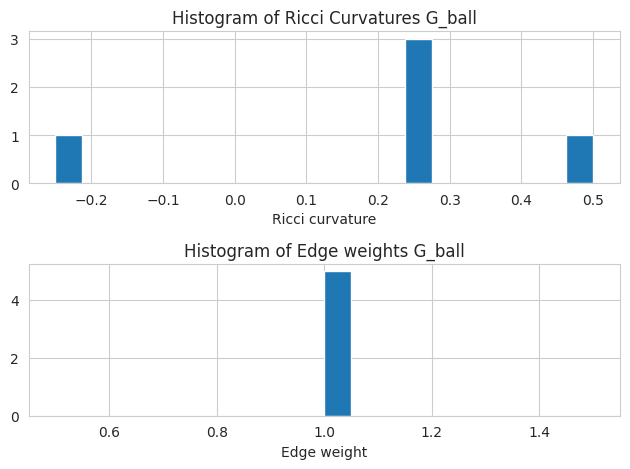

In [24]:
def show_results(G, curvature="ricciCurvature"):

    # Print the first five results
    print("Ball graph of center node 0")
    for n1,n2 in list(G.edges())[:5]:
        print("Ricci curvature of edge (%s,%s) is %f" % (n1 ,n2, G[n1][n2][curvature]))

    # Plot the histogram of Ricci curvatures
    plt.subplot(2, 1, 1)
    ricci_curvtures = nx.get_edge_attributes(G, curvature).values()
    plt.hist(ricci_curvtures,bins=20)
    plt.xlabel('Ricci curvature')
    plt.title("Histogram of Ricci Curvatures G_ball")

    # Plot the histogram of edge weights
    plt.subplot(2, 1, 2)
    weights = nx.get_edge_attributes(G, "weight").values()
    plt.hist(weights,bins=20)
    plt.xlabel('Edge weight')
    plt.title("Histogram of Edge weights G_ball")

    plt.tight_layout()

show_results(G_orc)

In [25]:
edge_atten = Edge_atten(in_channels=data.x.size(1), out_channels=64)

In [26]:
atten_probs = edge_atten(data.x, edge_list)
weights = torch.squeeze(atten_probs).detach().numpy()

In [27]:
ball_dict = {}
for i,(key, value) in enumerate(ricci_curvtures.items()):
    key, value = (key, value)
    ball_dict[key] = []
    ball_dict[key].append(value)
    ball_dict[key].append(weights[i])


In [28]:
key_list = list(ball_dict.keys())
val_list = list(ball_dict.values())

In [29]:
x, y = key_list[0]
x, y = torch.tensor(x), torch.tensor(y)
k = torch.tensor(val_list[0][0])
atten_weight = val_list[0][1]

In [30]:
x, y = feat[x], feat[y]

In [31]:
euclidean_dist = dist_e(x, y)
print(euclidean_dist)

tensor(15.4596)


In [32]:
poincare_dist = dist_p(x,y)
print(poincare_dist)

tensor(1.0965)


In [33]:
sphere_dist = dist_s(x, y)

In [34]:
print(sphere_dist)

tensor(1.4740)


In [20]:
def ball_dist(edge_list):
    edge_list_nx = list(tuple(i) for x, i in enumerate(edge_list.t().numpy()))
    g_ball = nx.Graph()
    g_ball.add_edges_from(edge_list_nx)
    orc= OllivierRicci(g_ball, alpha=0.5, verbose="TRACE")
    orc.compute_ricci_curvature()
    G_orc = orc.G.copy()
    ricci_curvatures = nx.get_edge_attributes(G_orc, "ricciCurvature")
    #print(ricci_curvatures)
    dist_ball = {}
    for key, value in ricci_curvatures.items():
        #print(key)
        dist_ball[key] = []
        x, y = feat[key[0]], feat[key[1]]
        euclidean_dist = dist_e(x, y)
        poincare_dist = dist_p(x,y)
        sphere_dist = dist_s(x, y)
        dist_ = euclidean_dist+poincare_dist+sphere_dist
        dist_ = round(float(dist_.detach().numpy()),2)
    # print(dist_ball[key])
        dist_ball[key].append(value)
        dist_ball[key].append(dist_)
    # print(dist_ball[key])
        # dist_ball[key].append(dist_)
    return dist_ball

In [21]:
dist_ball = ball_dist(edge_list)

In [22]:
dist_ball

{(0, 101): [-0.25, 18.03],
 (0, 122): [0.5, 9.65],
 (101, 8): [0.25, 15.3],
 (101, 20): [0.25, 16.95],
 (101, 109): [0.25, 16.54]}

In [30]:
for edge, value in dist_ball.items():
    #print(value[1])
    if value[1] <= 15.2:
        u, v = edge
        print([u,v])

[0, 122]


In [26]:
def star_rewire(dist_ball):
  dist_ = []
  for edge, value in dist_ball.items():
    dist_.append(value[1])
  print(np.mean(dist_))
  rewired_edges = []
  for edge, value in dist_ball.items():
    if value[1] <= np.mean(dist_):
      u,v = edge
      rewired_edges.append([u,v])
  return rewired_edges

In [27]:
rewired_edges = star_rewire(dist_ball)

15.294


In [25]:
rewired_edges

[[0, 122]]

In [31]:
edge_list = torch.permute(torch.tensor(rewired_edges, dtype=torch.long), (1,0))

In [32]:
edge_list

tensor([[  0],
        [122]])

In [105]:
for edge, values in dist_ball.items():
    print(edge)

(0, 101)
(0, 122)
(101, 8)
(101, 20)
(101, 109)


In [ ]:
weighted_edge_list = []
for index,edges in enumerate(edge_list):
    # for k in weights:
    #     weighted_edge_list.append((i,j)+(k))
    weighted_edge_list.append(edges+(weights[index],))
print(weighted_edge_list)

In [ ]:
g_ball = nx.Graph()
g_ball.add_weighted_edges_from(weighted_edge_list)

In [117]:
def ball_rewiring(dist_ball):
    weighted_edge_list = []
    for edge, values in dist_ball.items():
        weighted_edge_list.append(edge+(values[1],))
    g_rewire = nx.Graph()
    g_rewire.add_weighted_edges_from(weighted_edge_list)
    sp_dict = {}
    for index, node in enumerate(g_rewire.nodes()):
        length, path = nx.single_source_bellman_ford(g_rewire, node, weight='weight')
        if index not in sp_dict:
             sp_dict[index] = []
        sp_dict[index].append(length)
        #sp_dict[index].append(path)
    return sp_dict
    
        

In [118]:
sp_dict = ball_rewiring(dist_ball)
sp_dict

{0: [{0: 0,
   101: 18.03,
   122: 9.65,
   8: 33.33,
   20: 34.980000000000004,
   109: 34.57}],
 1: [{101: 0, 0: 18.03, 8: 15.3, 20: 16.95, 109: 16.54, 122: 27.68}],
 2: [{122: 0,
   0: 9.65,
   101: 27.68,
   8: 42.980000000000004,
   20: 44.629999999999995,
   109: 44.22}],
 3: [{8: 0, 101: 15.3, 0: 33.33, 20: 32.25, 109: 31.84, 122: 42.98}],
 4: [{20: 0,
   101: 16.95,
   0: 34.980000000000004,
   8: 32.25,
   109: 33.489999999999995,
   122: 44.63}],
 5: [{109: 0,
   101: 16.54,
   0: 34.57,
   8: 31.84,
   20: 33.489999999999995,
   122: 44.22}]}

In [135]:
def rewired_edges(sp_dict):
    rewired_edges = []
    for index, neighbours in sp_dict.items():
        radius = []
        for node, dist in neighbours[0].items():
            radius.append(dist)
        print(np.mean(radius))
        for node, dist in neighbours[0].items():
            if dist <= np.mean(radius):
                rewired_edges.append([index, node])
    return rewired_edges
    
    

In [136]:
rewired_ = rewired_edges(sp_dict)

21.76
15.75
28.19333333333333
25.95
27.05
26.776666666666667


In [137]:
rewired_

[[0, 0],
 [0, 101],
 [0, 122],
 [1, 101],
 [1, 8],
 [2, 122],
 [2, 0],
 [2, 101],
 [3, 8],
 [3, 101],
 [4, 20],
 [4, 101],
 [5, 109],
 [5, 101]]